<a href="https://colab.research.google.com/github/Kevin-Og99/beng_beng/blob/main/4_Cross_validation_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

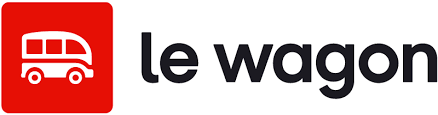

# Cross-validation

In this challenge, you will be introduced to a new concept: **cross-validation**.

Cross-validation is kind of similar to something you already know: **train-test split**.



Have a look at the diagram below. The upper part represents the **train-test split** which you already know. \
The lower part represents **cross-validation**.

![](https://wagon-public-datasets.s3.amazonaws.com/data-analytics/machine-learning/cross-validation.png)

As you can see, in the classic train-test split, we split the data in two sets: **train and test**.

In cross-validation, we further split the training set into *k* folds! In this case, *k* = 5. \
That means that 5 sub-models will be trained, and for each sub-model, 4 folds of data will be used for training and 1 fold will be used for testing. We will then compute the average test score of our sub-models, which is called a **cross-validated score**.


This is a very robust way to test the performance of our model, as we can make sure that each part of our data will be used at some point for testing.


## Import the data


We will be reusing the NBA dataset from the Regression challenge. 🏀


The dataset is available at this link: [https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/NBA.csv](https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/NBA.csv)


Load it into a `df`variable.


In [1]:
#your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

nba_df = pd.read_csv("https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/NBA.csv")
nba_df.head()

,season,poss,mp,do_ratio,pacing,win_rating
0,1987,4847,2409,-1.546275,-0.599918,1.643091
1,2017,5582,2708,0.996587,0.531888,10.808427
2,2016,4976,2407,0.242598,0.127976,3.054773
3,2021,1178,585,-1.343806,-1.201034,0.230004
4,1988,4534,2056,-1.813990,-0.128997,0.905614


## Define X and y

Same as in the previous challenges, we need to define the features and the target.

Create **X** and **y**.



In [3]:
#your code here
X3 = nba_df[['mp','poss','do_ratio','pacing']]
y3 = nba_df['win_rating']


## Train-test split



You know the drill by now, use Sklearn's `train_test_split` function to split your data into `X_train`, `X_test`, `y_train` and `y_test`.

In [6]:
#your code here
from sklearn.model_selection import train_test_split
X3_train, X3_test, y3_train, y3_test = train_test_split(X3,y3)

X3_train.shape, X3_test.shape, y3_train.shape, y3_test.shape



((3000, 4), (1000, 4), (3000,), (1000,))

## Scaling the features

Just like in the previous challenges we need to scale our numerical features.

Import and instantiate a scaler of your choice from the **Sklearn** library. \
Then, scale your features and save the results in two new variables named `X_train_scaled`and `X_test_scaled`.

In [10]:
#your code here
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X3_train_scaled = scaler.fit_transform(X3_train)
X3_test_scaled = scaler.transform(X3_test)

## Cross-validation

Now the fun begins! 🔥

Before cross-validating, we need to instantiate a model. \
Instantiate a **Linear Regression** model **without fitting it**.


In [11]:
#your code here
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()

### 5-fold cross-validation


Time to cross-validate! \
You will need to import the `cross_val_score` method.

Run a **5-fold** cross-validation on your Linear Regression model. Store the results in a `score`variable.



<details>
    <summary>Help 😵‍💫</summary>
    
Here's the framework:

`score = cross_val_score(estimator=your_model, X=your_features, y= your_target, cv = number_of_folds)`

</details>


In [16]:
#your code here
from sklearn.model_selection import cross_val_score
number_of_folds = 5

score = cross_val_score(estimator=lin_reg, X=X3_train_scaled, y= y3_train, cv =5)

score

array([0.63376157, 0.63936129, 0.59534953, 0.6377564 , 0.61866009])

What does it look like? \
If you ran the code properly, `score`should contain 5 individual R<sup>2</sup> values!



---

What's the mean score? Store it in a `score_five`variable.


In [17]:
#your code here ( Appliquer le Mean directement)
score_five = score.mean()
score_five

np.float64(0.6249777743893828)

### 10-fold cross-validation


Let's repeat the process, but this time with a **10-fold** cross-validation.

What does it imply in terms of sub-models ?



> **Your answer here (Double Click)**

Run the cross-validation, and store the results in a `score` variable.


In [19]:
score = cross_val_score(estimator=lin_reg, X=X3_train_scaled, y= y3_train, cv =10)
score

array([0.61752593, 0.65361085, 0.64017075, 0.64531608, 0.64139628,
       0.53708205, 0.60227778, 0.68126949, 0.58683253, 0.64918298])

In [ ]:
#your code here


array([0.66034234, 0.68830523, 0.61672066, 0.64085843, 0.51561554,
       0.65658044, 0.6778192 , 0.61558209, 0.6268206 , 0.66856555])

`score`should now contain 10 individual R<sup>2</sup> values!


---

What's the mean score? Store it in a `score_ten`variable.

In [20]:
#your code here
score_ten = score.mean()
score_ten

np.float64(0.6254664716259672)

## Evaluate on the test set



**IMPORTANT NOTE**

Cross-validation **does not** fit the model! We will have to train our Linear Regression model before going any further.

Fit the model on your train set.



In [ ]:
#your code here



Now score your fitted model on your test set.



In [ ]:
#your code here



Compare the value to `score_five`and `score_ten`. The results should be in the same range!




## Conclusion

Cross-validation is a robust technique used to assess the performance of Machine Learning models. \
By partitioning the dataset into multiple sub-sets, or **folds**, and iteratively training and testing on these different combinations, cross-validation provides a more comprehensive understanding of a model's ability to generalize to new data.

Congratulations for your first day of Machine Learning! 🎉
